In [ ]:
%cd ../..
import os
import polars as pl
import numpy as np
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, BatchSampler
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from tqdm import tqdm

from evaluation import *

random.seed(4)
np.random.seed(4)
torch.manual_seed(4)

/mnt/nas-0/hydra/ubs/shared/projects/outcomes/RM/radio-fm-legacy


In [2]:
embeddings_path = "/scratch/scratch1/embeddings/RSNA-PE/demo"

labels_df = pl.read_csv(os.path.join(embeddings_path, "labels.csv"))
labels_df = labels_df.filter((pl.col("num_img_pe") == 0) | (pl.col("num_img_pe") > 4))
labels_df.head()

series_uid,slice_idx,has_pe,num_img_pe
str,i64,bool,i64
"""387be8e8c47a""",0,false,0
"""387be8e8c47a""",1,false,0
"""387be8e8c47a""",2,false,0
"""387be8e8c47a""",3,false,0
"""387be8e8c47a""",4,false,0


In [3]:
sample_ratio = 1.0
train_size = 0.8

series_uids = labels_df["series_uid"].unique().to_list()
random.shuffle(series_uids)
num_samples = len(series_uids)
num_select_samples = int(sample_ratio * num_samples)
num_train_samples = int(train_size * num_select_samples)

series_uids = series_uids[:num_select_samples]

train_series_uids = series_uids[:num_train_samples]
val_series_uids = series_uids[num_train_samples:]

train_df = labels_df.filter(pl.col("series_uid").is_in(train_series_uids))
val_df = labels_df.filter(pl.col("series_uid").is_in(val_series_uids))

print(f"Total series_uids: {num_samples}")
print(f"Subsampling ratio {sample_ratio}")
print(f"Train ids: {len(train_df)}")
print(f"Val ids: {len(val_df)}")

Total series_uids: 7279
Subsampling ratio 1.0
Train ids: 138463
Val ids: 34399


In [4]:
def get_embedding(series_uid, slice_idx):
    x = torch.load(os.path.join(embeddings_path, f"{series_uid}.pth"), mmap=True)
    return x["cls"][slice_idx]

class RSNAPE(Dataset):
    def __init__(self, labels_df):
        self.labels_df = labels_df

    def __len__(self):
        return len(self.labels_df)
    
    def get_labels(self):
        return self.labels_df["has_pe"].to_list()
    
    def __getitem__(self, idx):
        series_uid, slice_idx, has_pe, _ = self.labels_df.row(idx)

        return get_embedding(series_uid, slice_idx), torch.tensor(has_pe, dtype=torch.float32)

In [5]:
train_dataset = RSNAPE(train_df)
val_dataset = RSNAPE(val_df)

In [6]:
class StratifiedBatchSampler(BatchSampler):
    def __init__(self, labels, batch_size, drop_last=False):
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.drop_last = drop_last

        assert batch_size % 2 == 0, "Batch size must be even for equal stratification."

        self.pos_indices = np.where(self.labels)[0].tolist()
        self.neg_indices = np.where(~self.labels)[0].tolist()

        self.num_batches = min(len(self.pos_indices), len(self.neg_indices)) * 2 // self.batch_size

    def __iter__(self):
        pos = np.random.permutation(self.pos_indices).tolist()
        neg = np.random.permutation(self.neg_indices).tolist()

        min_class_len = min(len(pos), len(neg))
        pos = pos[:min_class_len]
        neg = neg[:min_class_len]

        half_bs = self.batch_size // 2
        for i in range(0, min_class_len, half_bs):
            if i + half_bs > min_class_len:
                if self.drop_last:
                    break
            batch = pos[i:i+half_bs] + neg[i:i+half_bs]
            np.random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches

In [ ]:
def train_classifier(
    model,
    optimizer,
    loss_fn,
    train_dataloader,
    val_dataloader,
    num_epochs,
    device,
    select_criteria="loss",
    threshold=0.5,
):
    assert select_criteria in ["loss", "rocauc", "precision", "recall"]

    train_loss_list = []
    train_rocauc_list = []
    train_precision_list = []
    train_recall_list = []
    
    val_loss_list = []
    val_rocauc_list = []
    val_precision_list = []
    val_recall_list = []

    best_val_rocauc = 0.0
    best_val_loss = float("inf")
    best_val_precision = 0.0
    best_val_recall = 0.0
    best_model_state = model.state_dict()

    for epoch in range(num_epochs):

        # Training Phase
        train_all_labels = []
        train_all_predictions = []
        train_loss = 0.0

        model.train()
        for embeddings, labels in tqdm(train_dataloader, desc=f"Train {epoch+1}/{num_epochs}"):
            embeddings, labels = (
                embeddings.to(device),
                labels.to(device),
            )

            predictions = model(embeddings).flatten()
            loss = loss_fn(predictions, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_all_labels.append(labels.detach().cpu())
            train_all_predictions.append(predictions.detach().cpu())

        train_labels_cat = torch.cat(train_all_labels)
        train_predictions_cat = torch.cat(train_all_predictions)
        
        train_probabilities = torch.nn.functional.sigmoid(train_predictions_cat)
        
        avg_train_loss = train_loss / len(train_labels_cat)
        train_loss_list.append(avg_train_loss)
        
        train_rocauc = roc_auc_score(train_labels_cat, train_probabilities)
        train_rocauc_list.append(train_rocauc)

        train_binary_predictions = (train_probabilities >= threshold).long() 
        
        train_precision = precision_score(train_labels_cat, train_binary_predictions, zero_division=0)
        train_precision_list.append(train_precision)
        
        train_recall = recall_score(train_labels_cat, train_binary_predictions, zero_division=0)
        train_recall_list.append(train_recall)

        val_all_labels = []
        val_all_predictions = []
        val_loss = 0.0

        model.eval()
        with torch.no_grad():
            for embeddings, labels in tqdm(val_dataloader, desc=f"Valid {epoch+1}/{num_epochs}"):
                embeddings, labels = (
                    embeddings.to(device),
                    labels.to(device),
                )

                predictions = model(embeddings).flatten()
                loss = loss_fn(predictions, labels)

                val_loss += loss.item()
                val_all_labels.append(labels.detach().cpu())
                val_all_predictions.append(predictions.detach().cpu())

        val_labels_cat = torch.cat(val_all_labels)
        val_predictions_cat = torch.cat(val_all_predictions)
        
        val_probabilities = torch.nn.functional.sigmoid(val_predictions_cat)
        
        avg_val_loss = val_loss / len(val_labels_cat)
        val_loss_list.append(avg_val_loss)
        
        val_rocauc = roc_auc_score(val_labels_cat, val_probabilities)
        val_rocauc_list.append(val_rocauc)

        val_binary_predictions = (val_probabilities >= threshold).long()
        
        val_precision = precision_score(val_labels_cat, val_binary_predictions, zero_division=0)
        val_precision_list.append(val_precision)
        
        val_recall = recall_score(val_labels_cat, val_binary_predictions, zero_division=0)
        val_recall_list.append(val_recall)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            if select_criteria == "loss":
                best_model_state = model.state_dict()

        if val_rocauc > best_val_rocauc:
            best_val_rocauc = val_rocauc
            if select_criteria == "rocauc":
                best_model_state = model.state_dict()
                
        if val_precision > best_val_precision: 
            best_val_precision = val_precision
            if select_criteria == "precision":
                best_model_state = model.state_dict()
                
        if val_recall > best_val_recall: 
            best_val_recall = val_recall
            if select_criteria == "recall":
                best_model_state = model.state_dict()

    return {
        "train_loss": train_loss_list,
        "train_rocauc": train_rocauc_list,
        "train_precision": train_precision_list, # Added
        "train_recall": train_recall_list,      # Added
        "val_loss": val_loss_list,
        "val_rocauc": val_rocauc_list,
        "val_precision": val_precision_list,    # Added
        "val_recall": val_recall_list,          # Added
        "state_dict": best_model_state,
    }

In [8]:
def get_predictions(model, dataloader, device):
    all_labels = []
    all_predictions = []
    model.eval()
    with torch.no_grad():
        for embeddings, labels in dataloader:
            embeddings, labels = (
                embeddings.to(device),
                labels.to(device)
            )

            predictions = model(embeddings).flatten()
            all_labels.append(labels.cpu())
            all_predictions.append(predictions.cpu())

    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_labels, all_predictions


In [9]:
EMBED_DIM = 768
hidden_dim = 64
num_epochs = 30
batch_size = 512
learning_rate = 0.001
weight_decay = 0.01
dropout = 0.0

train_sampler = StratifiedBatchSampler(train_dataset.get_labels(), batch_size, drop_last=True)
train_dataloader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda")
model = nn.Sequential(
    nn.Linear(EMBED_DIM, hidden_dim),
    nn.ReLU(),
    nn.Dropout(dropout),
    nn.Linear(hidden_dim, 1)
).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

output = train_classifier(
    model,
    optimizer,
    loss_fn,
    train_dataloader,
    val_dataloader,
    num_epochs,
    device,
    select_criteria="rocauc",
)
model.load_state_dict(output["state_dict"])


Valid 30/30: 100%|██████████| 68/68 [00:10<00:00,  6.65it/s]


<All keys matched successfully>

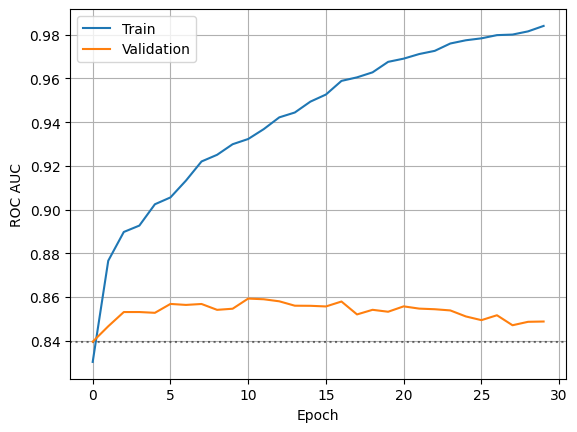

In [10]:
plot_train_curves(output["train_rocauc"], output["val_rocauc"], "ROC AUC")

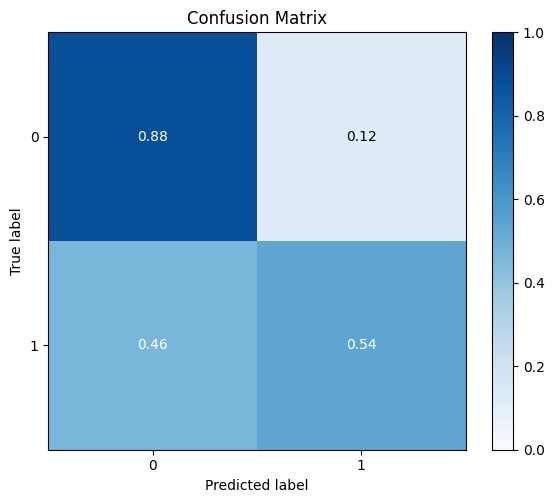

In [11]:
all_labels, all_predictions = get_predictions(model, val_dataloader, device)
all_predictions = all_predictions > 0.0

plot_confusion_matrix(all_labels, all_predictions)